# NASA CMAPSS — Combined ML Fault Detection
### Models: KNN · WNN · Decision Tree · Random Forest · Gaussian Naive Bayes
### 3-class target: Healthy (RUL > 75) · Degrading (RUL 36–75) · Critical (RUL ≤ 35)

## 1. Imports

In [1]:
import os
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_predict
from sklearn.metrics import (
    accuracy_score, classification_report,
    recall_score, precision_score, f1_score,
    make_scorer
)

from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB

from imblearn.over_sampling import SMOTE

SEED = 42
pd.set_option('display.max_rows', None)

## 2. Load Data

In [2]:
index_names   = ['unit_nr', 'time_cycles']
setting_names = ['setting_1', 'setting_2', 'setting_3']
sensor_names  = ['s_{}'.format(i) for i in range(1, 22)]
col_names     = index_names + setting_names + sensor_names

# ── Update this path to point at your local CMAPSSData folder ──────────────
path = r"C:\Users\hamil\OneDrive\Desktop\UNI\Year 3\Year 3 Sem 1\ENGG2112"


df = pd.read_csv(os.path.join(path, 'train_FD001.txt'),
                 sep=r'\s+', header=None, names=col_names)

## 3. Compute RUL & Classifier Labels

In [3]:
max_cycle = df.groupby('unit_nr')['time_cycles'].max()
df = df.merge(max_cycle.to_frame('max_cycle'), left_on='unit_nr', right_index=True)
df['RUL'] = df['max_cycle'] - df['time_cycles']
df = df.drop('max_cycle', axis=1)


# ── Classifier labels ──────────────────────────────────────────────────────
class_names = ['healthy', 'degrading', 'critical']

def rul_to_class(rul):
    if rul > 75:   return 0   # healthy
    elif rul > 35: return 1   # degrading
    else:          return 2   # critical

df['RUL_class'] = df['RUL'].apply(rul_to_class)

print('Class distribution in training set:')
print(df['RUL_class'].value_counts().rename(index={0:'healthy', 1:'degrading', 2:'critical'}))

Class distribution in training set:
RUL_class
healthy      13031
degrading     4000
critical      3600
Name: count, dtype: int64


## 4. Drop Low-Variance Features

In [4]:
# ── Drop low-variance features ─────────────────────────────────────────────
df = df.drop('setting_3', axis=1)

candidate_cols = [c for c in df.columns if c.startswith('s_') or c.startswith('setting_')]
low_var_cols   = [c for c in candidate_cols if df[c].var() < 1e-6]
print(f'Dropping {len(low_var_cols)} low-variance column(s): {low_var_cols}')
df = df.drop(columns=low_var_cols)

# ── Train/test split (75:25) ───────────────────────────────────────────────
from sklearn.model_selection import train_test_split

feature_cols = [c for c in df.columns
                if c not in ['unit_nr', 'time_cycles', 'RUL', 'RUL_class']]

X = df[feature_cols]
y = df['RUL_class']

X_train_raw, X_test_raw, y_train, y_test_class = train_test_split(
    X, y, test_size=0.25, random_state=SEED, stratify=y
)

print(f'X_train shape: {X_train_raw.shape}')
print(f'X_test  shape: {X_test_raw.shape}')
print('Class distribution — train:')
print(y_train.value_counts().rename({0:'healthy', 1:'degrading', 2:'critical'}))

Dropping 7 low-variance column(s): ['setting_2', 's_1', 's_5', 's_10', 's_16', 's_18', 's_19']
X_train shape: (15473, 16)
X_test  shape: (5158, 16)
Class distribution — train:
RUL_class
healthy      9773
degrading    3000
critical     2700
Name: count, dtype: int64


## 5. SMOTE — Balance Training Classes

In [5]:
smote = SMOTE(random_state=SEED)
X_train_smote, y_train_smote = smote.fit_resample(X_train_raw, y_train)

print('Class distribution after SMOTE:')
print(pd.Series(y_train_smote).value_counts().rename({0:'healthy', 1:'degrading', 2:'critical'}))

Class distribution after SMOTE:
RUL_class
healthy      9773
degrading    9773
critical     9773
Name: count, dtype: int64


## 6. Scaled Datasets
StandardScaler is applied for KNN/WNN and GNB (distance- and probability-based algorithms).
Decision Tree and Random Forest receive unscaled data (tree splits are scale-invariant).

In [6]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_smote)   # fit on SMOTE-balanced training data
X_test_scaled  = scaler.transform(X_test_raw)           # apply same scale to test set

# Unscaled (tree-based models)
X_train_unscaled = X_train_smote
X_test_unscaled  = X_test_raw

In [7]:
print(f'\nX_train shape : {X_train_raw.shape}')
print(f'X_test  shape : {X_test_raw.shape}')
print(f'Features      : {feature_cols}')


X_train shape : (15473, 16)
X_test  shape : (5158, 16)
Features      : ['setting_1', 's_2', 's_3', 's_4', 's_6', 's_7', 's_8', 's_9', 's_11', 's_12', 's_13', 's_14', 's_15', 's_17', 's_20', 's_21']


## 7. Cross-Validation Setup & Threshold-Tuning Helper

In [8]:
CV_FOLDS = 5
skf = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=SEED)

CV_SCORING = {
    'accuracy'        : 'accuracy',
    'f1_macro'        : 'f1_macro',
    'recall_macro'    : 'recall_macro',
    'recall_critical' : make_scorer(recall_score, labels=[2], average='macro'),
}

RECALL_TARGET   = 0.90   # minimum acceptable critical-class recall
PRECISION_FLOOR = 0.50   # minimum acceptable critical-class precision


def tune_critical_threshold(model, X_tr, y_tr, cv, thresholds=None):
    """
    Select the probability threshold for the critical class using
    out-of-fold (cross-validated) predictions — never the test set.

    Returns
    -------
    chosen_threshold : float
    """
    if thresholds is None:
        thresholds = np.arange(0.05, 0.55, 0.025)

    y_proba_cv = cross_val_predict(
        model, X_tr, y_tr, cv=cv,
        method='predict_proba', n_jobs=-1
    )

    cv_recalls, cv_precisions = [], []
    for t in thresholds:
        y_tmp = np.where(y_proba_cv[:, 2] > t,
                         2,
                         y_proba_cv[:, :2].argmax(axis=1))
        cv_recalls.append(
            recall_score(y_tr, y_tmp, labels=[2], average='macro', zero_division=0))
        cv_precisions.append(
            precision_score(y_tr, y_tmp, labels=[2], average='macro', zero_division=0))

    cv_recalls    = np.array(cv_recalls)
    cv_precisions = np.array(cv_precisions)

    valid = (cv_recalls >= RECALL_TARGET) & (cv_precisions >= PRECISION_FLOOR)
    if valid.any():
        chosen_idx = np.where(valid)[0][-1]   # highest threshold that still meets target
    else:
        feasible = cv_precisions >= PRECISION_FLOOR
        if feasible.any():
            chosen_idx = np.argmax(np.where(feasible, cv_recalls, -1))
        else:
            chosen_idx = np.argmax(cv_recalls)

    chosen_threshold = thresholds[chosen_idx]
    print(f'  CV critical recall   : {cv_recalls[chosen_idx]:.3f}')
    print(f'  CV critical precision: {cv_precisions[chosen_idx]:.3f}')
    return chosen_threshold


def apply_threshold(model, X_test, threshold):
    """Apply a custom critical-class probability threshold at inference time."""
    y_proba = model.predict_proba(X_test)
    return np.where(y_proba[:, 2] > threshold,
                    2,
                    y_proba[:, :2].argmax(axis=1))


def print_results(model_name, y_true, y_pred, cv_results, threshold):
    """
    Print a standardised performance summary for one model.
    """
    sep = '=' * 60
    print(f'\n{sep}')
    print(f'  {model_name}')
    print(sep)

    # ── 5-fold CV metrics ──────────────────────────────────────────────────
    print(f'\n  5-Fold Stratified CV (on SMOTE-balanced training data):')
    for metric in ['accuracy', 'f1_macro', 'recall_macro', 'recall_critical']:
        scores = cv_results[f'test_{metric}']
        print(f'    {metric:<22}: {scores.mean():.4f} ± {scores.std():.4f}')

    # ── Hold-out test set ──────────────────────────────────────────────────
    print(f'\n  Hold-out Test Set (critical threshold = {threshold:.3f}):')
    print(f'    Accuracy: {accuracy_score(y_true, y_pred):.4f}')
    print()
    print(classification_report(y_true, y_pred,
                                target_names=class_names,
                                digits=4))

## 8. KNN (K=5, uniform weights)

In [9]:
print('── KNN ──────────────────────────────────────────────')
knn = KNeighborsClassifier(n_neighbors=5, weights='uniform', metric='minkowski', n_jobs=-1)

# 5-fold cross-validation
knn_cv = cross_validate(knn, X_train_scaled, y_train_smote,
                        cv=skf, scoring=CV_SCORING, n_jobs=-1)

# Threshold tuning via out-of-fold predictions
print('  Tuning critical threshold...')
knn.fit(X_train_scaled, y_train_smote)   # refit on full training set
knn_threshold = tune_critical_threshold(
    KNeighborsClassifier(n_neighbors=5, weights='uniform', metric='minkowski', n_jobs=-1),
    X_train_scaled, y_train_smote, skf
)
print(f'  Chosen threshold: {knn_threshold:.3f}')

# Apply threshold at test time
y_pred_knn = apply_threshold(knn, X_test_scaled, knn_threshold)

print_results('KNN  (K=5, uniform weights)', y_test_class, y_pred_knn, knn_cv, knn_threshold)

── KNN ──────────────────────────────────────────────
  Tuning critical threshold...
  CV critical recall   : 0.941
  CV critical precision: 0.946
  Chosen threshold: 0.525

  KNN  (K=5, uniform weights)

  5-Fold Stratified CV (on SMOTE-balanced training data):
    accuracy              : 0.8564 ± 0.0029
    f1_macro              : 0.8569 ± 0.0029
    recall_macro          : 0.8564 ± 0.0029
    recall_critical       : 0.9414 ± 0.0023

  Hold-out Test Set (critical threshold = 0.525):
    Accuracy: 0.7441

              precision    recall  f1-score   support

     healthy     0.9227    0.7514    0.8283      3258
   degrading     0.4094    0.6550    0.5038      1000
    critical     0.8122    0.8167    0.8144       900

    accuracy                         0.7441      5158
   macro avg     0.7148    0.7410    0.7155      5158
weighted avg     0.8039    0.7441    0.7630      5158



## 9. WNN (K=5, distance-weighted)

In [10]:
print('── WNN ──────────────────────────────────────────────')
wnn = KNeighborsClassifier(n_neighbors=5, weights='distance', metric='minkowski', n_jobs=-1)

# 5-fold cross-validation
wnn_cv = cross_validate(wnn, X_train_scaled, y_train_smote,
                        cv=skf, scoring=CV_SCORING, n_jobs=-1)

# Threshold tuning
print('  Tuning critical threshold...')
wnn.fit(X_train_scaled, y_train_smote)
wnn_threshold = tune_critical_threshold(
    KNeighborsClassifier(n_neighbors=5, weights='distance', metric='minkowski', n_jobs=-1),
    X_train_scaled, y_train_smote, skf
)
print(f'  Chosen threshold: {wnn_threshold:.3f}')

# Apply threshold at test time
y_pred_wnn = apply_threshold(wnn, X_test_scaled, wnn_threshold)

print_results('WNN  (K=5, distance weights)', y_test_class, y_pred_wnn, wnn_cv, wnn_threshold)

── WNN ──────────────────────────────────────────────
  Tuning critical threshold...
  CV critical recall   : 0.957
  CV critical precision: 0.963
  Chosen threshold: 0.525

  WNN  (K=5, distance weights)

  5-Fold Stratified CV (on SMOTE-balanced training data):
    accuracy              : 0.8749 ± 0.0026
    f1_macro              : 0.8746 ± 0.0027
    recall_macro          : 0.8749 ± 0.0026
    recall_critical       : 0.9630 ± 0.0025

  Hold-out Test Set (critical threshold = 0.525):
    Accuracy: 0.7437

              precision    recall  f1-score   support

     healthy     0.9236    0.7498    0.8277      3258
   degrading     0.4092    0.6580    0.5046      1000
    critical     0.8122    0.8167    0.8144       900

    accuracy                         0.7437      5158
   macro avg     0.7150    0.7415    0.7156      5158
weighted avg     0.8044    0.7437    0.7627      5158



## 10. Decision Tree (max_depth=8)

In [11]:
print('── Decision Tree ────────────────────────────────────')
dt = DecisionTreeClassifier(max_depth=8, criterion='gini',
                             min_samples_leaf=3, random_state=SEED)

# 5-fold cross-validation
dt_cv = cross_validate(dt, X_train_unscaled, y_train_smote,
                       cv=skf, scoring=CV_SCORING, n_jobs=-1)

# Threshold tuning
print('  Tuning critical threshold...')
dt.fit(X_train_unscaled, y_train_smote)
dt_threshold = tune_critical_threshold(
    DecisionTreeClassifier(max_depth=8, criterion='gini',
                            min_samples_leaf=3, random_state=SEED),
    X_train_unscaled, y_train_smote, skf
)
print(f'  Chosen threshold: {dt_threshold:.3f}')

# Apply threshold at test time
y_pred_dt = apply_threshold(dt, X_test_unscaled, dt_threshold)

print_results('Decision Tree  (max_depth=8)', y_test_class, y_pred_dt, dt_cv, dt_threshold)

── Decision Tree ────────────────────────────────────
  Tuning critical threshold...
  CV critical recall   : 0.903
  CV critical precision: 0.860
  Chosen threshold: 0.325

  Decision Tree  (max_depth=8)

  5-Fold Stratified CV (on SMOTE-balanced training data):
    accuracy              : 0.8012 ± 0.0042
    f1_macro              : 0.8037 ± 0.0044
    recall_macro          : 0.8012 ± 0.0042
    recall_critical       : 0.8492 ± 0.0051

  Hold-out Test Set (critical threshold = 0.325):
    Accuracy: 0.7980

              precision    recall  f1-score   support

     healthy     0.9245    0.8303    0.8748      3258
   degrading     0.4906    0.6490    0.5588      1000
    critical     0.8383    0.8467    0.8425       900

    accuracy                         0.7980      5158
   macro avg     0.7511    0.7753    0.7587      5158
weighted avg     0.8253    0.7980    0.8079      5158



## 11. Random Forest (n_estimators=200)

In [12]:
print('── Random Forest ────────────────────────────────────')
rf = RandomForestClassifier(
    n_estimators=200, max_features='sqrt',
    class_weight='balanced', bootstrap=True,
    random_state=SEED, n_jobs=-1
)

# 5-fold cross-validation
rf_cv = cross_validate(rf, X_train_unscaled, y_train_smote,
                       cv=skf, scoring=CV_SCORING, n_jobs=-1)

# Threshold tuning
print('  Tuning critical threshold...')
rf.fit(X_train_unscaled, y_train_smote)
rf_threshold = tune_critical_threshold(
    RandomForestClassifier(
        n_estimators=200, max_features='sqrt',
        class_weight='balanced', bootstrap=True,
        random_state=SEED, n_jobs=-1
    ),
    X_train_unscaled, y_train_smote, skf
)
print(f'  Chosen threshold: {rf_threshold:.3f}')

# Apply threshold at test time
y_pred_rf = apply_threshold(rf, X_test_unscaled, rf_threshold)

print_results('Random Forest  (n_estimators=200)', y_test_class, y_pred_rf, rf_cv, rf_threshold)

── Random Forest ────────────────────────────────────
  Tuning critical threshold...
  CV critical recall   : 0.925
  CV critical precision: 0.969
  Chosen threshold: 0.525

  Random Forest  (n_estimators=200)

  5-Fold Stratified CV (on SMOTE-balanced training data):
    accuracy              : 0.8971 ± 0.0044
    f1_macro              : 0.8975 ± 0.0045
    recall_macro          : 0.8971 ± 0.0044
    recall_critical       : 0.9380 ± 0.0036

  Hold-out Test Set (critical threshold = 0.525):
    Accuracy: 0.8387

              precision    recall  f1-score   support

     healthy     0.9139    0.9030    0.9084      3258
   degrading     0.5798    0.6360    0.6066      1000
    critical     0.8884    0.8311    0.8588       900

    accuracy                         0.8387      5158
   macro avg     0.7940    0.7900    0.7913      5158
weighted avg     0.8447    0.8387    0.8413      5158



## 12. Gaussian Naive Bayes

In [13]:
print('── Gaussian Naive Bayes ─────────────────────────────')
gnb = GaussianNB(var_smoothing=1e-9)

# 5-fold cross-validation
gnb_cv = cross_validate(gnb, X_train_scaled, y_train_smote,
                        cv=skf, scoring=CV_SCORING, n_jobs=-1)

# Threshold tuning
print('  Tuning critical threshold...')
gnb.fit(X_train_scaled, y_train_smote)
gnb_threshold = tune_critical_threshold(
    GaussianNB(var_smoothing=1e-9),
    X_train_scaled, y_train_smote, skf
)
print(f'  Chosen threshold: {gnb_threshold:.3f}')

# Apply threshold at test time
y_pred_gnb = apply_threshold(gnb, X_test_scaled, gnb_threshold)

print_results('Gaussian Naive Bayes  (var_smoothing=1e-9)', y_test_class, y_pred_gnb, gnb_cv, gnb_threshold)

── Gaussian Naive Bayes ─────────────────────────────
  Tuning critical threshold...
  CV critical recall   : 0.963
  CV critical precision: 0.741
  Chosen threshold: 0.525

  Gaussian Naive Bayes  (var_smoothing=1e-9)

  5-Fold Stratified CV (on SMOTE-balanced training data):
    accuracy              : 0.7309 ± 0.0038
    f1_macro              : 0.7225 ± 0.0040
    recall_macro          : 0.7309 ± 0.0038
    recall_critical       : 0.9637 ± 0.0051

  Hold-out Test Set (critical threshold = 0.525):
    Accuracy: 0.7061

              precision    recall  f1-score   support

     healthy     0.9449    0.6998    0.8041      3258
   degrading     0.3433    0.4960    0.4057      1000
    critical     0.6662    0.9622    0.7873       900

    accuracy                         0.7061      5158
   macro avg     0.6514    0.7193    0.6657      5158
weighted avg     0.7796    0.7061    0.7239      5158



## 13. Overall Results Summary

In [14]:
models = {
    'KNN  (K=5, uniform)'   : (y_pred_knn, knn_cv, knn_threshold),
    'WNN  (K=5, distance)'  : (y_pred_wnn, wnn_cv, wnn_threshold),
    'Decision Tree (d=8)'   : (y_pred_dt,  dt_cv,  dt_threshold),
    'Random Forest (n=200)' : (y_pred_rf,  rf_cv,  rf_threshold),
    'Gaussian NB'           : (y_pred_gnb, gnb_cv, gnb_threshold),
}

rows = []
for name, (y_pred, cv_res, thr) in models.items():
    cv_acc  = cv_res['test_accuracy']
    cv_f1   = cv_res['test_f1_macro']
    cv_rec  = cv_res['test_recall_critical']
    rows.append({
        'Model'                   : name,
        'CV Accuracy (mean±std)'  : f"{cv_acc.mean():.4f} ± {cv_acc.std():.4f}",
        'CV F1-macro (mean±std)'  : f"{cv_f1.mean():.4f} ± {cv_f1.std():.4f}",
        'CV Crit. Recall (mean)'  : f"{cv_rec.mean():.4f}",
        'Threshold'               : f"{thr:.3f}",
        'Test Accuracy'           : f"{accuracy_score(y_test_class, y_pred):.4f}",
        'Test F1-macro'           : f"{f1_score(y_test_class, y_pred, average='macro'):.4f}",
        'Test Crit. Recall'       : f"{recall_score(y_test_class, y_pred, labels=[2], average='macro', zero_division=0):.4f}",
    })

summary_df = pd.DataFrame(rows).set_index('Model')

print('\n' + '=' * 100)
print('  OVERALL PERFORMANCE SUMMARY')
print('=' * 100)
print(summary_df.to_string())
print('=' * 100)
print('\nNote: CV metrics are from 5-fold stratified cross-validation on SMOTE-balanced training data.')
print('      Test metrics use the hold-out set with the CV-selected critical-class threshold.')


  OVERALL PERFORMANCE SUMMARY
                      CV Accuracy (mean±std) CV F1-macro (mean±std) CV Crit. Recall (mean) Threshold Test Accuracy Test F1-macro Test Crit. Recall
Model                                                                                                                                             
KNN  (K=5, uniform)          0.8564 ± 0.0029        0.8569 ± 0.0029                 0.9414     0.525        0.7441        0.7155            0.8167
WNN  (K=5, distance)         0.8749 ± 0.0026        0.8746 ± 0.0027                 0.9630     0.525        0.7437        0.7156            0.8167
Decision Tree (d=8)          0.8012 ± 0.0042        0.8037 ± 0.0044                 0.8492     0.325        0.7980        0.7587            0.8467
Random Forest (n=200)        0.8971 ± 0.0044        0.8975 ± 0.0045                 0.9380     0.525        0.8387        0.7913            0.8311
Gaussian NB                  0.7309 ± 0.0038        0.7225 ± 0.0040                 0.9

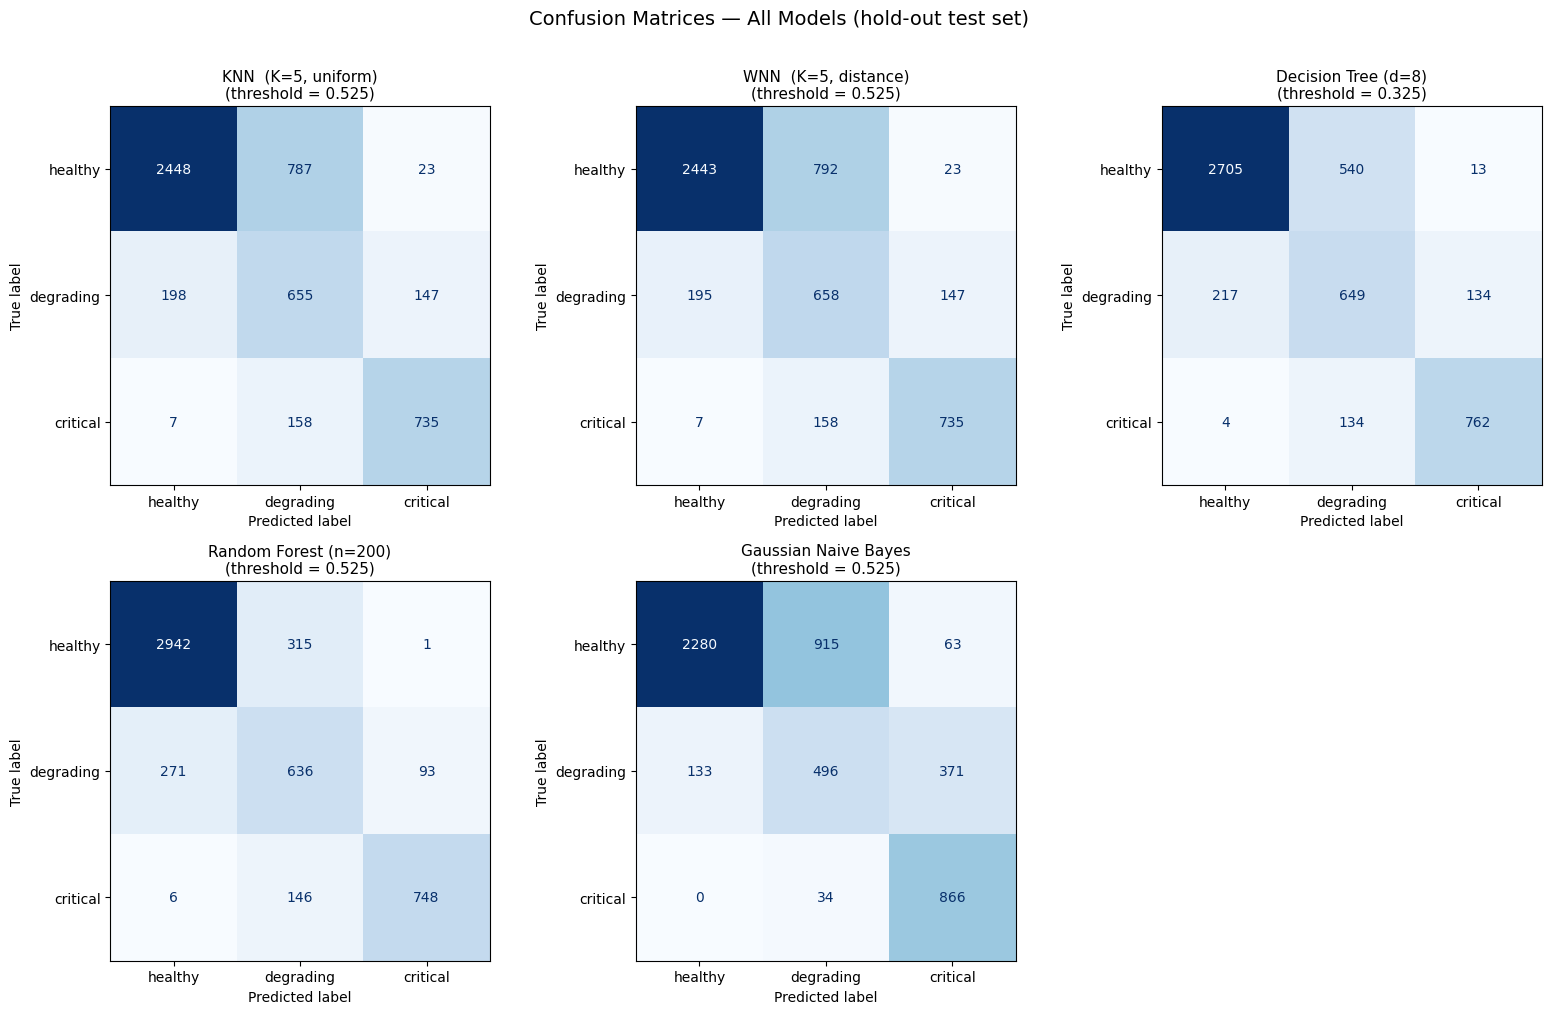

In [15]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

model_preds = [
    ('KNN  (K=5, uniform)',   y_pred_knn, knn_threshold),
    ('WNN  (K=5, distance)',  y_pred_wnn, wnn_threshold),
    ('Decision Tree (d=8)',   y_pred_dt,  dt_threshold),
    ('Random Forest (n=200)', y_pred_rf,  rf_threshold),
    ('Gaussian Naive Bayes',  y_pred_gnb, gnb_threshold),
]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for ax, (name, y_pred, thr) in zip(axes, model_preds):
    cm = confusion_matrix(y_test_class, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(cmap='Blues', ax=ax, colorbar=False)
    ax.set_title(f'{name}\n(threshold = {thr:.3f})', fontsize=11)
    ax.set_xlabel('Predicted label')
    ax.set_ylabel('True label')

# Hide the unused 6th subplot
axes[-1].set_visible(False)

fig.suptitle('Confusion Matrices — All Models (hold-out test set)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()